
# Fase 2 — Modelos de Regresión Supervisada

**Curso:** Machine Learning I (MCDI504)  
**Grupo:** [Grupo 8]  
**Integrantes:** [Jennifer Nilo, Patricio Núñez ]  
**Fecha:** [Fecha de entrega]  
**Repositorio:**  https://github.com/pnunezcarreno/machinelearning1

**Ruta del notebook en el repositorio:** [notebook/F2_Regresion.ipynb]




# I. Introducción y contextualización — C1

El presente notebook implementa modelos de **regresión supervisada** utilizando el dataset **California Housing**. En este tipo de problemas, la variable objetivo es continua y se busca estimar un valor numérico a partir de variables explicativas (Ruete, 2026e).

El conjunto California Housing contiene información demográfica y habitacional de distritos censales de California. La variable objetivo es `MedHouseVal`, que representa el valor mediano de las viviendas expresado en cientos de miles de dólares (Ruete, 2026b).

### Situación de análisis

El valor de una vivienda puede estar relacionado con factores socioeconómicos, habitacionales y geográficos. El análisis busca evaluar el desempeño de distintos modelos para predecir `MedHouseVal`.

### Objetivo analítico

Implementar y comparar:

1. una **regresión lineal simple**;
2. un **árbol de decisión para regresión**;
3. una **red neuronal MLP para regresión**.

Los modelos serán evaluados mediante **MSE, RMSE y R²** sobre un conjunto de prueba.


In [ ]:

# Librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Semilla para reproducibilidad
SEMILLA = 42
np.random.seed(SEMILLA)

TEST_SIZE = 0.20



# II. Descripción del conjunto de datos y preprocesamiento — C2

Las variables del dataset son (Ruete, 2026b):

| Variable | Descripción |
|---|---|
| `MedInc` | Ingreso mediano del distrito |
| `HouseAge` | Edad media de las viviendas |
| `AveRooms` | Número medio de habitaciones |
| `AveBedrms` | Número medio de dormitorios |
| `Population` | Población del distrito |
| `AveOccup` | Número medio de ocupantes por hogar |
| `Latitude` | Latitud |
| `Longitude` | Longitud |
| `MedHouseVal` | Valor mediano de las viviendas (**variable objetivo**) |

Para cumplir con la regresión lineal **simple**, este modelo utilizará únicamente `MedInc` como predictor. `MedInc` es una variable especialmente informativa para explicar el valor de las viviendas (Ruete, 2026b).

Para el árbol de decisión y la red neuronal se utilizarán las ocho variables predictoras disponibles.

El preprocesamiento contempla:

- revisión de valores faltantes;
- selección de variables;
- partición entrenamiento/prueba;
- escalamiento para la red neuronal.


In [ ]:

# Carga del dataset
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()

print(f"Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
display(df.head())


Dimensiones del dataset: 20640 filas x 9 columnas


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



## 2.1. Tratamiento de valores faltantes

Se verifica la presencia de valores faltantes. Si el dataset no contiene nulos, no se requiere eliminación ni imputación.


In [ ]:

# Valores faltantes
nulos = df.isnull().sum().to_frame("Valores_nulos")
display(nulos)

if nulos["Valores_nulos"].sum() == 0:
    print("El dataset no presenta valores faltantes; no se requiere eliminación ni imputación.")
else:
    print("Se detectaron valores faltantes y deben ser tratados antes del modelamiento.")


,Valores_nulos
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


El dataset no presenta valores faltantes; no se requiere eliminación ni imputación.



## 2.2. Selección de variables y partición entrenamiento/prueba

- **Variable objetivo:** `MedHouseVal`.
- **Regresión lineal simple:** utiliza únicamente `MedInc`.
- **Árbol de decisión:** utiliza las ocho variables predictoras.
- **Red neuronal MLP:** utiliza las ocho variables predictoras.

La regresión lineal simple relaciona una única variable independiente con una variable dependiente (Ruete, 2026e).

Se utilizará una partición **80 % entrenamiento / 20 % prueba** y `random_state=42`. Los tres modelos utilizarán exactamente las mismas observaciones de entrenamiento y prueba.

Para la red neuronal se aplicará `StandardScaler`, ajustado exclusivamente con los datos de entrenamiento.


In [ ]:

# Variables
target = "MedHouseVal"
features = housing.feature_names

X_full = df[features].copy()
X_simple = df[["MedInc"]].copy()
y = df[target].copy()

# Se dividen los índices para garantizar las mismas observaciones
# de entrenamiento y prueba en los tres modelos.
indices_train, indices_test = train_test_split(
    df.index,
    test_size=TEST_SIZE,
    random_state=SEMILLA
)

# Regresión lineal simple
X_train_simple = X_simple.loc[indices_train]
X_test_simple = X_simple.loc[indices_test]

# Árbol y MLP
X_train_full = X_full.loc[indices_train]
X_test_full = X_full.loc[indices_test]

# Objetivo común
y_train = y.loc[indices_train]
y_test = y.loc[indices_test]

print(f"Entrenamiento: {len(indices_train)} registros")
print(f"Prueba: {len(indices_test)} registros")

# Escalamiento para MLP
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_full_scaled = scaler.transform(X_test_full)


Entrenamiento: 16512 registros
Prueba: 4128 registros



# III. Modelo de regresión lineal simple — C3

La regresión lineal simple modela la relación entre una variable predictora y una variable objetivo continua (Ruete, 2026e):

\[
$y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... + \beta_nx_n + \epsilon$
]

En este caso:

- **Predictor:** `MedInc`.
- **Objetivo:** `MedHouseVal`.
- **Modelo:** `LinearRegression()`.


In [ ]:

# Regresión lineal simple
linear_model = LinearRegression()
linear_model.fit(X_train_simple, y_train)

y_pred_linear = linear_model.predict(X_test_simple)

mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print("--- Regresión Lineal Simple ---")
print(f"Intercepto: {linear_model.intercept_:.4f}")
print(f"Coeficiente MedInc: {linear_model.coef_[0]:.4f}")
print(f"MSE : {mse_linear:.4f}")
print(f"RMSE: {rmse_linear:.4f}")
print(f"R²  : {r2_linear:.4f}")

display(Markdown(
    f"""
**Interpretación.** El modelo obtuvo un **MSE de {mse_linear:.4f}**,
un **RMSE de {rmse_linear:.4f}** y un **R² de {r2_linear:.4f}**.
El R² indica que `MedInc`, como único predictor, explica aproximadamente
**{r2_linear*100:.2f}%** de la variabilidad de `MedHouseVal` en el conjunto de prueba.
"""
))


--- Regresión Lineal Simple ---
Intercepto: 0.4446
Coeficiente MedInc: 0.4193
MSE : 0.7091
RMSE: 0.8421
R²  : 0.4589



**Interpretación.** El modelo obtuvo un **MSE de 0.7091**,
un **RMSE de 0.8421** y un **R² de 0.4589**.
El R² indica que `MedInc`, como único predictor, explica aproximadamente
**45.89%** de la variabilidad de `MedHouseVal` en el conjunto de prueba.



# IV. Modelo de árbol de decisión para regresión — C4

Un árbol de regresión divide el espacio de variables en regiones y asigna una predicción a cada región, lo que permite capturar relaciones no lineales (Ruete, 2026c).

### Ficha técnica

| Hiperparámetro | Valor |
|---|---:|
| `max_depth` | `5` |
| `random_state` | `42` |

Se utilizan las ocho variables predictoras disponibles.


In [ ]:

# Árbol de decisión
decision_tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=SEMILLA
)

decision_tree_model.fit(X_train_full, y_train)
y_pred_tree = decision_tree_model.predict(X_test_full)

mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("--- Árbol de Decisión ---")
print(f"MSE : {mse_tree:.4f}")
print(f"RMSE: {rmse_tree:.4f}")
print(f"R²  : {r2_tree:.4f}")

display(Markdown(
    f"""
**Interpretación.** El árbol obtuvo un **MSE de {mse_tree:.4f}**,
un **RMSE de {rmse_tree:.4f}** y un **R² de {r2_tree:.4f}**.
Estas métricas permiten evaluar su capacidad predictiva sobre datos no utilizados durante el entrenamiento.
"""
))


--- Árbol de Decisión ---
MSE : 0.5245
RMSE: 0.7242
R²  : 0.5997



**Interpretación.** El árbol obtuvo un **MSE de 0.5245**,
un **RMSE de 0.7242** y un **R² de 0.5997**.
Estas métricas permiten evaluar su capacidad predictiva sobre datos no utilizados durante el entrenamiento.



# V. Modelo de red neuronal MLP para regresión — C5

Las redes neuronales MLP pueden modelar relaciones no lineales mediante capas de neuronas y funciones de activación (Ruete, 2026d).

### Ficha técnica

| Hiperparámetro | Valor |
|---|---|
| `hidden_layer_sizes` | `(100,)` |
| `activation` | `relu` |
| `solver` | `adam` |
| `max_iter` | `500` |
| `early_stopping` | `True` |
| `random_state` | `42` |

Se utilizan las ocho variables predictoras escaladas.


In [ ]:

# Red neuronal MLP
mlp_model = MLPRegressor(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=SEMILLA,
    early_stopping=True
)

mlp_model.fit(X_train_full_scaled, y_train)
y_pred_mlp = mlp_model.predict(X_test_full_scaled)

mse_mlp = mean_squared_error(y_test, y_pred_mlp)
rmse_mlp = np.sqrt(mse_mlp)
r2_mlp = r2_score(y_test, y_pred_mlp)

print("--- Red Neuronal MLP ---")
print(f"MSE : {mse_mlp:.4f}")
print(f"RMSE: {rmse_mlp:.4f}")
print(f"R²  : {r2_mlp:.4f}")

display(Markdown(
    f"""
**Interpretación.** La red neuronal obtuvo un **MSE de {mse_mlp:.4f}**,
un **RMSE de {rmse_mlp:.4f}** y un **R² de {r2_mlp:.4f}**.
El resultado refleja su desempeño sobre el mismo conjunto de prueba utilizado por los demás modelos.
"""
))


--- Red Neuronal MLP ---
MSE : 0.3017
RMSE: 0.5493
R²  : 0.7697



**Interpretación.** La red neuronal obtuvo un **MSE de 0.3017**,
un **RMSE de 0.5493** y un **R² de 0.7697**.
El resultado refleja su desempeño sobre el mismo conjunto de prueba utilizado por los demás modelos.



# VI. Evaluación de modelos de regresión — C6

La evaluación se realiza mediante las tres métricas.
 (Ruete, 2026a; Ruete, 2026e):

- **MSE:** error cuadrático medio.
- **RMSE:** raíz del error cuadrático medio.
- **R²:** proporción de variabilidad explicada por el modelo.

Un menor MSE y RMSE indica menor error, mientras que un mayor R² indica mayor capacidad explicativa.


In [ ]:

# Reporte tabulado de métricas
results = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal Simple",
        "Árbol de Decisión",
        "Red Neuronal MLP"
    ],
    "MSE": [mse_linear, mse_tree, mse_mlp],
    "RMSE": [rmse_linear, rmse_tree, rmse_mlp],
    "R²": [r2_linear, r2_tree, r2_mlp]
})

display(
    results.style.format({
        "MSE": "{:.4f}",
        "RMSE": "{:.4f}",
        "R²": "{:.4f}"
    })
)


,Modelo,MSE,RMSE,R²
0,Regresión Lineal Simple,0.7091,0.8421,0.4589
1,Árbol de Decisión,0.5245,0.7242,0.5997
2,Red Neuronal MLP,0.3017,0.5493,0.7697


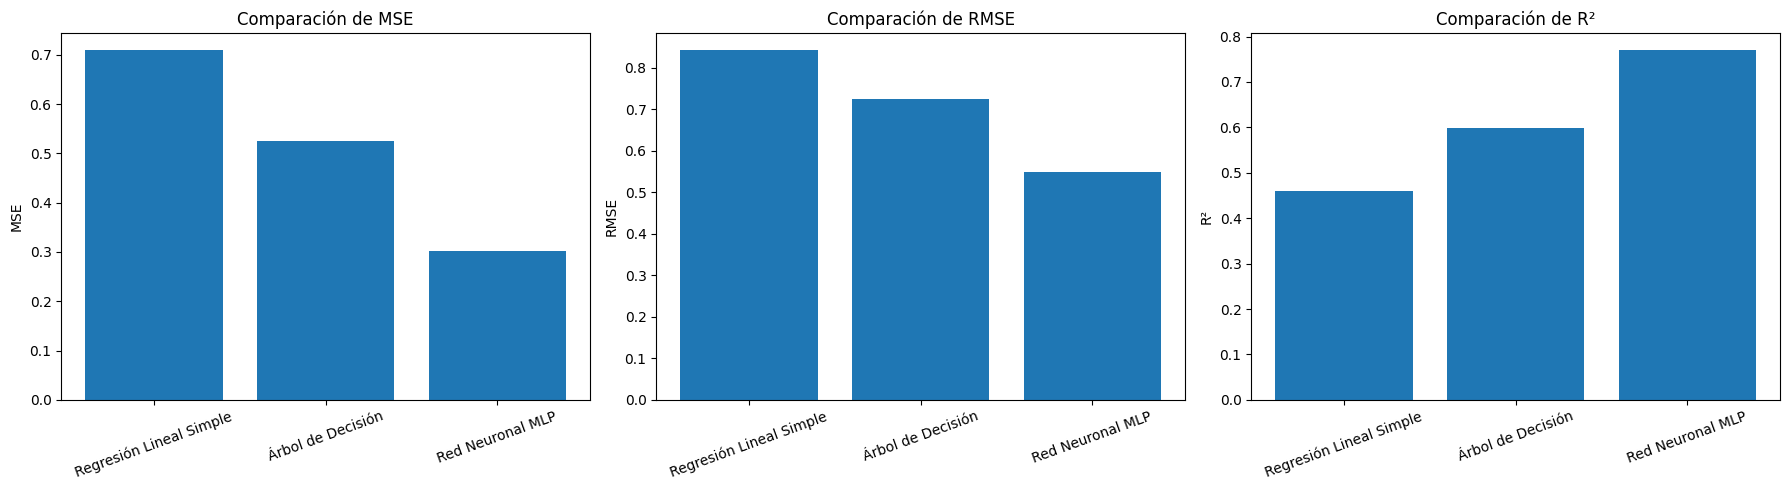

In [ ]:

# Visualización comparativa para utilizar como figura del análisis/anexos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(results["Modelo"], results["MSE"])
axes[0].set_title("Comparación de MSE")
axes[0].set_ylabel("MSE")

axes[1].bar(results["Modelo"], results["RMSE"])
axes[1].set_title("Comparación de RMSE")
axes[1].set_ylabel("RMSE")

axes[2].bar(results["Modelo"], results["R²"])
axes[2].set_title("Comparación de R²")
axes[2].set_ylabel("R²")

for ax in axes:
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()



# VII. Comparación de modelos — C7

La comparación considera las métricas obtenidas, además de las fortalezas y limitaciones de cada enfoque.

| Modelo | Fortalezas | Limitaciones |
|---|---|---|
| **Regresión lineal simple** | Alta interpretabilidad y simplicidad | Solo utiliza `MedInc` y representa una relación lineal |
| **Árbol de decisión** | Captura relaciones no lineales y utiliza múltiples predictores | Puede sobreajustar si aumenta demasiado su complejidad |
| **Red neuronal MLP** | Capacidad para modelar relaciones no lineales complejas | Menor interpretabilidad y mayor dependencia de hiperparámetros |

**Consideración metodológica:** la regresión lineal simple utiliza un solo predictor, mientras que el árbol y la MLP utilizan las ocho variables predictoras. Por ello, la comparación de desempeño refleja tanto diferencias entre algoritmos como diferencias en la cantidad de información de entrada.


In [ ]:

# Identificación del modelo con mejor desempeño según RMSE
results_sorted = results.sort_values(
    by=["RMSE", "R²"],
    ascending=[True, False]
).reset_index(drop=True)

best = results_sorted.iloc[0]

display(Markdown(
    f"""
### Resultado comparativo

El modelo con mejor desempeño según el criterio de **menor RMSE** es
**{best['Modelo']}**, con:

- **MSE:** {best['MSE']:.4f}
- **RMSE:** {best['RMSE']:.4f}
- **R²:** {best['R²']:.4f}

La elección se justifica por presentar el menor error de predicción entre los tres modelos evaluados.
No obstante, la interpretación debe considerar que el modelo lineal utiliza un solo predictor, mientras
que el árbol y la red neuronal utilizan las ocho variables disponibles.
"""
))



### Resultado comparativo

El modelo con mejor desempeño según el criterio de **menor RMSE** es
**Red Neuronal MLP**, con:

- **MSE:** 0.3017
- **RMSE:** 0.5493
- **R²:** 0.7697

La elección se justifica por presentar el menor error de predicción entre los tres modelos evaluados.
No obstante, la interpretación debe considerar que el modelo lineal utiliza un solo predictor, mientras
que el árbol y la red neuronal utilizan las ocho variables disponibles.



# VIII. Notebook y documentación del proceso — C8

El flujo del notebook mantiene correspondencia con los apartados del informe:

| Apartado del informe | Sección del notebook |
|---|---|
| Descripción del conjunto de datos y preprocesamiento | II |
| Regresión lineal simple | III |
| Árbol de decisión | IV |
| Red neuronal MLP | V |
| Evaluación | VI |
| Comparación | VII |
| Conclusiones | IX |

El archivo `F2_Regresion.ipynb` debe mantenerse en el repositorio del proyecto junto con el informe y la documentación correspondiente.



# IX. Conclusiones — C9

La fase permitió implementar los tres modelos solicitados y evaluarlos mediante MSE, RMSE y R².

La regresión lineal simple utiliza `MedInc` como único predictor, mientras que el árbol de decisión y la red neuronal utilizan las ocho variables disponibles. El modelo con menor RMSE corresponde al de mejor desempeño predictivo dentro de esta ejecución.

La comparación también muestra que la selección de un modelo debe considerar sus ventajas y limitaciones, además de las métricas obtenidas. Para la continuidad del proyecto, estos resultados constituyen la base para posteriores ajustes y evaluaciones.



# X. Referencias

- Ruete, D. (2026a). *Evaluación de modelos de regresión* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026b). *Modelos de aprendizaje supervisado - Regresión* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026c). *Regresión con árboles de decisión* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026d). *Regresión con redes neuronales artificiales* [Apunte]. Universidad Andrés Bello.
- Ruete, D. (2026e). *Regresión lineal simple, polinomial y multivariable* [Apunte]. Universidad Andrés Bello.
